# Imports

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tigramite.plotting as tp
from tigramite.causal_effects import CausalEffects
from tigramite.data_processing import DataFrame
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from tigramite.independence_tests.parcorr import ParCorr


#from utils import load_ts_df

In [86]:
def load_ts_df(
    file_path: Path, 
) -> pd.DataFrame:
    """Load q/climate ts df from LamaH-CE, and change index to datetime."""

    df = pd.read_csv(filepath_or_buffer=file_path, header=0, sep=";")

    df_date_index = (df
    .assign(date=pd.to_datetime(df.rename(columns={"DD": "day", "MM": "month", "YYYY": "year"})[["year", "month", "day"]]))
    .drop(columns=["DD", "MM", "YYYY"])
    .set_index("date")
    )

    return df_date_index

# Data

In [87]:
lamah_ce_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily")

climate_ts_802_path = lamah_ce_path / "B_basins_intermediate_all/2_timeseries/daily/ID_802.csv"
q_ts_802_path = lamah_ce_path / "D_gauges/2_timeseries/daily/ID_802.csv"

In [88]:
climate_ts_802_df = load_ts_df(climate_ts_802_path) 
q_ts_802_df = load_ts_df(q_ts_802_path) 

In [89]:
climate_ts_802_df.columns

Index(['DOY', '2m_temp_max', '2m_temp_mean', '2m_temp_min', '2m_dp_temp_max',
       '2m_dp_temp_mean', '2m_dp_temp_min', '10m_wind_u', '10m_wind_v',
       'fcst_alb', 'lai_high_veg', 'lai_low_veg', 'swe',
       'surf_net_solar_rad_max', 'surf_net_solar_rad_mean',
       'surf_net_therm_rad_max', 'surf_net_therm_rad_mean', 'surf_press',
       'total_et', 'prec', 'volsw_123', 'volsw_4'],
      dtype='str')

# 1. Graph-Validation 

Check that the distribution is markov to the graph. 

In [90]:
# Just pick the variables in the graph (climate + discharge)
climate_vars_df = climate_ts_802_df.loc[:, ["2m_temp_mean", "prec", "total_et", "volsw_123", "swe"]]
vars_df = pd.concat([climate_vars_df, q_ts_802_df["qobs"]], axis=1)

In [91]:
# define tigramite graph and plot it 

N = len(vars_df.columns)
tau_max = 1

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 


# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 1] = "-->" # lagged on prec (reseach for alps)
graph[0, 2, 1] = "-->" # lagged on et (set to lag, as et instantenous impacts temp instantly (it rains, it gets colder)) 
graph[0, 3, 1] = "-->" # lagged impact on sm to avod temp -> sm -> et -> temp cycle
graph[0, 4, 0] = "-->" # impact on swe
graph[4, 0, 0] = "<--" # reverse

# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm
graph[3, 1, 0] = "<--" # reverse
graph[1, 4, 0] = "-->" # impact on swe
graph[4, 1, 0] = "<--" # reverse
graph[1, 5, 0] = "-->" # impact on q
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 0, 0] = "-->" # impact on temp 
graph[0, 2, 0] = "<--" # reverse
graph[2, 1, 1] = "-->" # lagged impact on prec
graph[2, 3, 1] = "-->" # impact on sm
graph[2, 4, 0] = "-->" # impact on swe
graph[4, 2, 0] = "<--" # reverse
graph[2, 5, 0] = "-->" # impact on q
graph[5, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation
graph[3, 2, 0] = "-->" # impact on et
graph[2, 3, 0] = "<--" # reverse
graph[3, 4, 0] = "-->" # impact on swe
graph[4, 3, 0] = "<--" # reverse
graph[3, 5, 0] = "-->" # impact on q
graph[5, 3, 0] = "<--" # reverse

# swe 
graph[4, 4, 1] = "-->" # self causation
graph[4, 5, 0] = "-->" # impact on qobs 
graph[5, 4, 0] = "<--" # reverse

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 640x480 with 1 Axes>, <Axes: >)

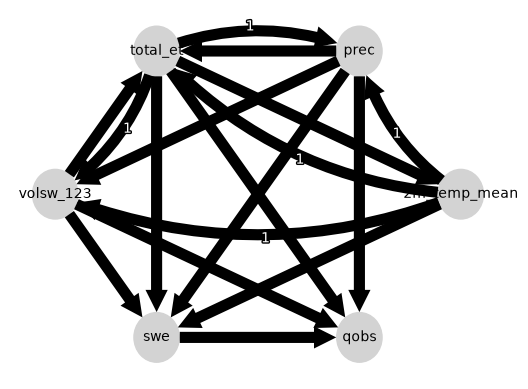

In [92]:
tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns
)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

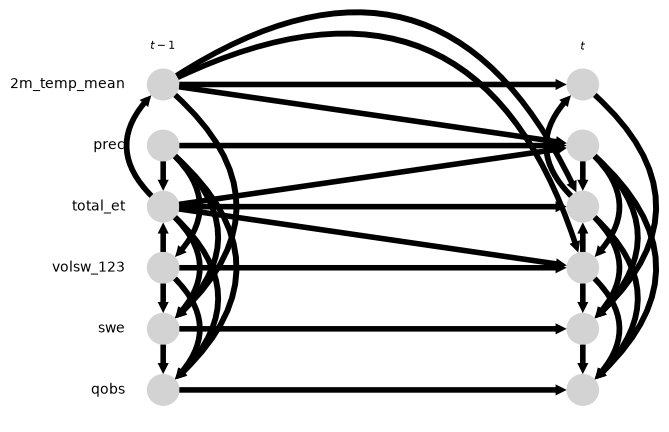

In [93]:
tp.plot_time_series_graph(graph=graph, var_names=vars_df.columns, curved_radius=0.6)

In [94]:
X = [(4,0)]
Y = [(5, 0)]
causal_effects = CausalEffects(graph=graph, graph_type="stationary_dag", X=X, Y=Y, check_SM_overlap=True, verbosity=1)


##
## Initializing CausalEffects class
##

Input:

graph_type = stationary_dag
X = [(4, 0)]
Y = [(5, 0)]
S = []
M = []





In [95]:
opt = causal_effects.get_optimal_set()
print("Oset = ", [(vars_df.columns[v[0]], v[1]) for v in opt])

Oset =  [('prec', np.int64(0)), ('qobs', np.int64(-1)), ('total_et', np.int64(0)), ('volsw_123', np.int64(0))]


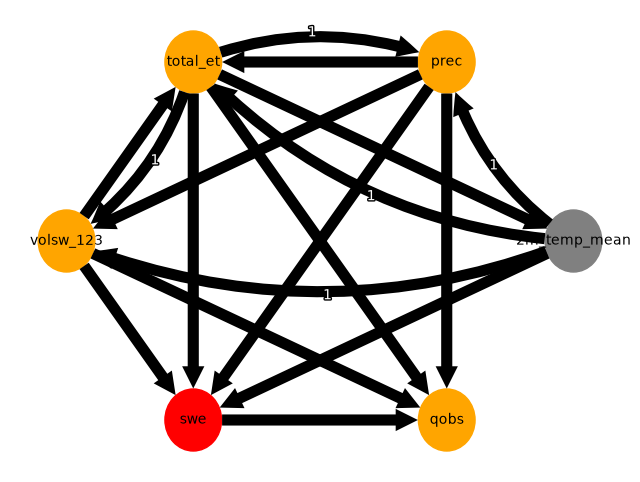

In [96]:
special_nodes = {}
for node in causal_effects.X:
    special_nodes[node] = 'red'
for node in causal_effects.Y:
    special_nodes[node] = 'blue'
for node in opt:
    special_nodes[node] = 'orange'
for node in causal_effects.M:
    special_nodes[node] = 'lightblue'

tp.plot_graph(graph = graph,
        var_names=vars_df.columns, 
#         save_name='Example.pdf',
        figsize = (8, 6),
        special_nodes=special_nodes,
        ); plt.show()

In [97]:
optimality = causal_effects.check_optimality()
print("(Graph, X, Y, S) fulfills optimality: ", optimality)

Optimality = True with cond_0 = False, cond_I = True, cond_II = True
(Graph, X, Y, S) fulfills optimality:  True


In [98]:
np.nan_to_num(vars_df.to_numpy())

array([[-1.0500e+01,  5.5700e+00, -8.0000e-02,  4.2000e-01,  2.6894e+02,
         1.5200e+00],
       [-1.2000e+01,  1.0660e+01,  0.0000e+00,  4.2000e-01,  2.7709e+02,
         1.4260e+00],
       [-7.8000e+00,  1.1990e+01, -6.0000e-02,  4.2000e-01,  2.8597e+02,
         1.4440e+00],
       ...,
       [-9.0000e+00,  0.0000e+00,  7.0000e-02,  4.3000e-01,  3.1319e+02,
         0.0000e+00],
       [-1.1200e+01,  0.0000e+00,  2.0000e-02,  4.3000e-01,  3.1317e+02,
         0.0000e+00],
       [-7.9000e+00,  0.0000e+00,  2.0000e-02,  4.3000e-01,  3.1321e+02,
         0.0000e+00]], shape=(14244, 6))

In [99]:
data_tg = DataFrame(data=np.nan_to_num(vars_df.to_numpy()))

In [100]:
causal_effects.fit_total_effect(
    dataframe=data_tg,
    estimator=KNeighborsRegressor(),
    adjustment_set="optimal"
)

In [101]:
causal_effects.model.fit_results["model"]

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [102]:
intervention_data = 1.*np.ones((1, 1))
y1 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
#         conditions_data=conditions_data,
        )
print("y1 = ",y1)

intervention_data = 0.*np.ones((1, 1))
y2 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
#         conditions_data=conditions_data,
        )
print("y2 = ",y2)

y1 =  [5.11641481]
y2 =  [5.17581722]


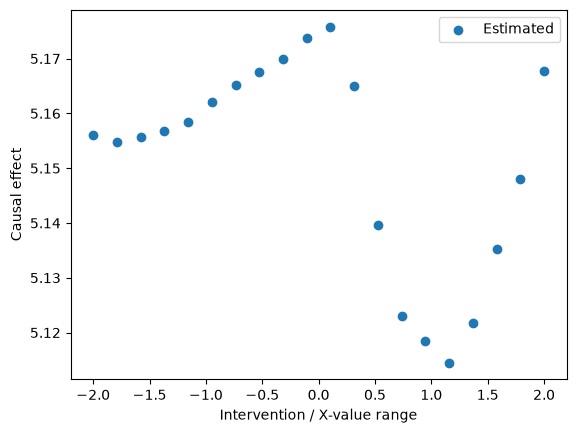

In [103]:
intervention_data = np.tile(np.linspace(-2, 2, 20).reshape(20, 1), (1, 1))
estimated_causal_effects = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
#         conditions_data=conditions_data,
        )
plt.scatter(intervention_data[:,0], estimated_causal_effects, label="Estimated")
# plt.plot(intervention_values, true_causal_effects, 'k-', label="True")
# plt.title(r"NRMSE = %.2f" % (np.abs(estimated_causal_effects - true_causal_effects).mean()/true_causal_effects.std()))
plt.xlabel('Intervention / X-value range')
plt.ylabel('Causal effect')
plt.legend()
plt.show()